### PyTorch를 통한 모델 서빙 (로컬 Windows + Jupyter + FastAPI 버전)

### 1 프로젝트 개요

- 본 프로젝트는 BERT 기반 텍스트 분류 모델을 학습하고, 이를 API 형태로 서빙하는 전체 파이프라인을 구현하는 것을 목표로 한다.

- AG News 데이터셋을 활용하여 뉴스 텍스트를 4개의 카테고리로 분류하는 모델을 구축하였으며,학습된 모델을 저장한 후 FastAPI 기반 REST API 서버로 배포하여 외부 요청에 대해 실시간 예측이 가능하도록 구성하였다.

- 특히 기존 TorchServe 방식 대신 FastAPI를 활용하여 로컬 환경에서 간단하고 직관적인 서빙 구조를 구현하고, ngrok을 통해 외부에서도 접근 가능한 테스트 환경을 구축하였다.


#### 목차

- 1 개발 환경 및 준비
- 2 데이터 청일 및 전처리
- 3 모델 구출 및 학습
- 4 모델 평가 및 검증
- 5 모델 저장 및 서빙 준비
- 6 모델 서빙 및 API 구축
- 7 외부 서비스 연동
- 8 결론 및 확장 방향

---
#### 회고
- TorchServe 기반 구조를 환경 의존성과 설정 복잡도를 고려하여 FastAPI로 전환하면서 서빙 구조를 이해하는데 도움이 되었다.
- 또한 ngrok을 통해 로컬 서버를 외부에 노출시키면서, 모델이 단순한 코드 결과가 아니라 실제 서비스 형태로 동작할 수 있다는 점을 체감할 수 있었다.

> - TorchServe 기반 모델 서빙 예제를 Windows 로컬 환경에서 FastAPI로 대체하였습니다.
> - 즉, **TorchServe 부분만 FastAPI로 전환**한 버전입니다.

#### 참고
- 개인 전화번호로 새로운 계정을 너무 많이 생성해서 추가 계정 생성에 제한되었습니다.
- 따라서 GCP에서만 할 수 있는 것만 GCP를 사용하고, 이번 프로젝트와 같은 경우는 로컬 PC에서 진행하게 되었습니다.


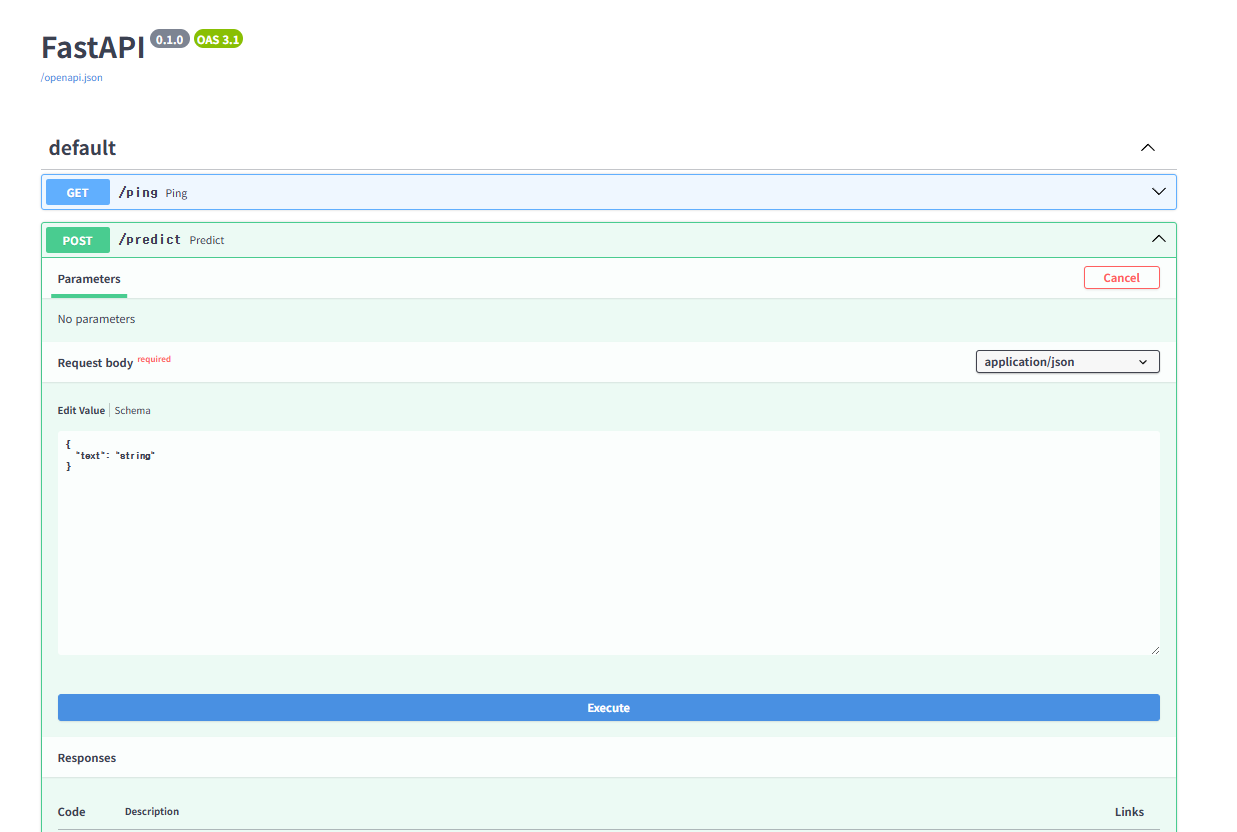
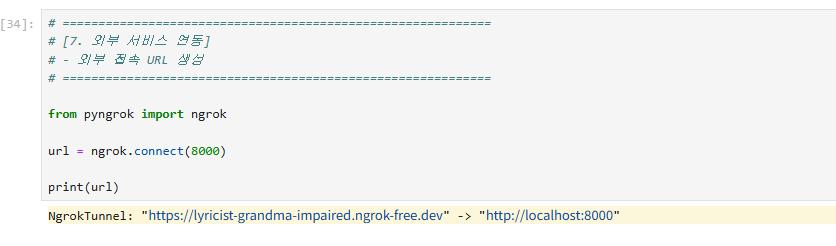
---

## 1. 개발 환경 및 준비 
- 1.1 환경 설정 및 라이브러리 설치 
- 1.2 주요 라이브러리 로드 
---

In [2]:
# ============================================================
# [1. 개발 환경 및 준비]
# - 프로젝트 실행에 필요한 라이브러리를 설치
# - TorchServe 대신 FastAPI 기반으로 서빙 구조를 구성
# ============================================================

# !pip install torch torchvision torchaudio
# !pip install transformers datasets scikit-learn matplotlib seaborn tqdm
# !pip install fastapi uvicorn python-multipart requests nest_asyncio pyngrok

In [7]:
# ============================================================
# [1. 개발 환경 및 준비]
# - 학습, 평가, API 서버 구성을 위한 라이브러리 import
# ============================================================

import os
import json
import threading
import time
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import nest_asyncio

from tqdm import tqdm
from torch.utils.data import DataLoader
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report

from transformers import BertTokenizer, BertForSequenceClassification
#from transformers import AdamW
from torch.optim import AdamW

### 2. 데이터 처리 및 전처리
- 2.1 데이터셋 로드 
- 2.2 텍스트 토큰화 및 전처리 
- 2.3 데이터 로더 구성 
---

In [12]:
# ============================================================
# [2. 데이터 처리 및 전처리]
# - AG News 데이터셋 로드
# - BERT 토크나이저를 이용한 텍스트 전처리
# - DataLoader 구성
# ============================================================

dataset = load_dataset("ag_news")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def preprocess_data(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset  = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

## 3. 모델 구축 및 학습 
- 3.1 BERT 기반 분류 모델 정의 
- 3.2 학습 설정 및 학습 수행 
- 3.3 학습 과정 모니터링 
---

In [15]:
# ============================================================
# [3. 모델 구축 및 학습]
# - BERT 기반 분류 모델 생성
# - 학습 수행
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

optimizer = AdamW(model.parameters(), lr=5e-5)

model.to(device)

num_epochs = 3
losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader):
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
            "labels": batch["label"].to(device),
        }

        outputs = model(**inputs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        losses.append(loss.item())

    print(f"Epoch {epoch+1} Loss:", total_loss / len(train_loader))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|████████████████████████████████

Epoch 1 Loss: 0.6297661465406418


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:07<00:00, 19.66it/s]


Epoch 2 Loss: 0.3073321160922448


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:07<00:00, 19.75it/s]

Epoch 3 Loss: 0.1462580539720754


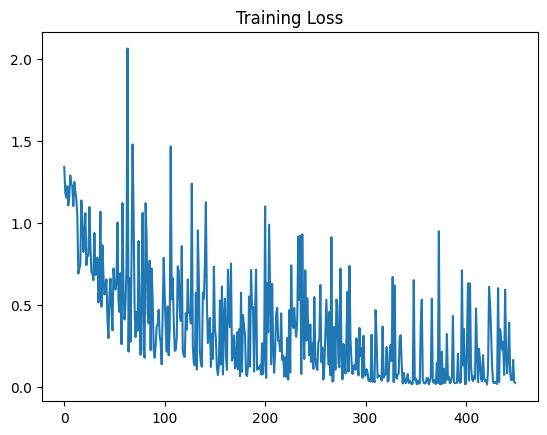

In [17]:
# ============================================================
# [3. 모델 구축 및 학습]
# - 학습 과정 모니터링 (Loss 시각화)
# ============================================================

plt.plot(losses)
plt.title("Training Loss")
plt.show()

### 4. 모델 평가 및 검증 
- 4.1 테스트 데이터 평가 
- 4.2 성능 지표 분석 (Accuracy, Confusion Matrix) 
- 4.3 단일 문장 예측 테스트 
---

In [19]:
# ============================================================
# [4. 모델 평가 및 검증]
# - 테스트 데이터로 정확도 평가
# ============================================================

model.eval()

correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }
        labels = batch["label"].to(device)

        outputs = model(**inputs)
        preds = outputs.logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

print("Accuracy:", correct / total)

Accuracy: 0.77125


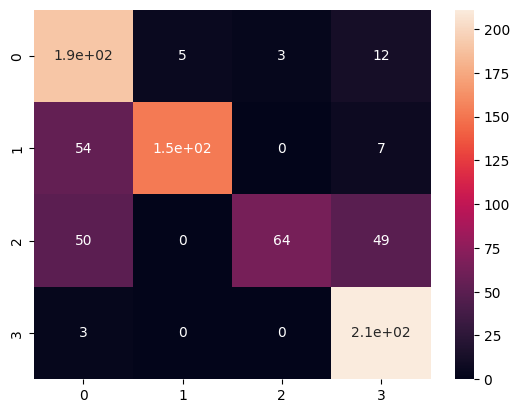

              precision    recall  f1-score   support

           0       0.64      0.90      0.75       210
           1       0.97      0.71      0.82       213
           2       0.96      0.39      0.56       163
           3       0.76      0.99      0.86       214

    accuracy                           0.77       800
   macro avg       0.83      0.75      0.75       800
weighted avg       0.82      0.77      0.76       800



In [21]:
# ============================================================
# [4. 모델 평가 및 검증]
# - Confusion Matrix 및 분류 리포트
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True)
plt.show()

print(classification_report(all_labels, all_preds))

In [23]:
# ============================================================
# [4. 모델 평가 및 검증]
# - 단일 문장 테스트
# ============================================================

text = "Apple reported strong earnings this quarter."

inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    logits = model(**inputs).logits
    pred = logits.argmax().item()

print("Prediction:", pred)

Prediction: 3


### 5. 모델 저장 및 서빙 준비
- 5.1 모델 저장 
- 5.2 서빙 구조 설계 (TorchServe → FastAPI 전환) 
- 5.3 FastAPI 서버 코드 구성 
---

In [25]:
# ============================================================
# [5. 모델 저장 및 서빙 준비]
# - 학습된 모델 저장
# ============================================================

MODEL_DIR = Path("fastapi_service")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "model.pth"
torch.save(model.state_dict(), MODEL_PATH)

In [27]:
# ============================================================
# [5. 모델 저장 및 서빙 준비]
# - TorchServe 대신 FastAPI로 서빙 구조 구현
# ============================================================

code = f"""
import torch
from fastapi import FastAPI
from pydantic import BaseModel
from transformers import BertTokenizer, BertForSequenceClassification

app = FastAPI()

device = torch.device("cpu")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
model.load_state_dict(torch.load("{MODEL_PATH}", map_location=device))
model.eval()

class Input(BaseModel):
    text: str

@app.get("/ping")
def ping():
    return {{"status": "ok"}}

@app.post("/predict")
def predict(inp: Input):
    x = tokenizer(inp.text, return_tensors="pt")
    with torch.no_grad():
        logits = model(**x).logits
        pred = logits.argmax().item()
    return {{"prediction": pred}}
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(code)

### 6. 모델 서빙 및 API 구축 
- 6.1 FastAPI 서버 실행 
- 6.2 API 엔드포인트 구성 (/predict, /ping) 
- 6.3 로컬 API 테스트 
---

In [30]:
# ============================================================
# [6. 모델 서빙 및 API 구축]
# - FastAPI 서버 실행 (TorchServe 대체)
# ============================================================

import uvicorn
import nest_asyncio
import threading

nest_asyncio.apply()

def run():
    uvicorn.run("app:app", host="0.0.0.0", port=8000)

threading.Thread(target=run, daemon=True).start()

time.sleep(3)
print("http://localhost:8000/docs")

D:\PyProject\AIFFEL_AI\LLM\MLOps\MLOps04\app.py:13: SyntaxWarning: invalid escape sequence '\m'
  model.load_state_dict(torch.load("fastapi_service\model.pth", map_location=device))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
INFO:     Started server process [439

http://localhost:8000/docs


In [32]:
# ============================================================
# [6. 모델 서빙 및 API 구축]
# - 로컬 API 테스트
# ============================================================

resp = requests.post(
    "http://localhost:8000/predict",
    json={"text": "The team won the match"}
)

print(resp.json())

INFO:     127.0.0.1:60781 - "POST /predict HTTP/1.1" 200 OK
{'prediction': 1}


In [ ]:
###  7. 외부 서비스 연동 (선택) 
- 7.1 ngrok을 통한 외부 접속 설정 
- 7.2 외부 API 테스트 
---

In [34]:
# ============================================================
# [7. 외부 서비스 연동]
# - 외부 접속 URL 생성
# ============================================================

from pyngrok import ngrok

url = ngrok.connect(8000)

print(url)

NgrokTunnel: "https://lyricist-grandma-impaired.ngrok-free.dev" -> "http://localhost:8000"


### 8. 결론 및 확장 방향
---

#### 결론

- BERT 기반 텍스트 분류 모델을 구축하고 API로 서빙함
- TorchServe 대신 FastAPI로 간단하고 직관적인 서빙 구현
- 로컬 환경에서 바로 실행 가능

#### 확장 방향
- Docker 기반 배포
- AWS / GCP Cloud Run 연결
- MLOps (CI/CD, 모델 버전관리)